In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchmetrics
import seaborn as sns
import scanpy as sc
from scipy.stats import ttest_rel
import sys


from cellwhisperer.config import config

sys.path.append(str(config["PROJECT_ROOT"]) + "/src/figures/notebooks/zero_shot_validation_scripts/")
sys.path.append(str(config["PROJECT_ROOT"]) + "/src/figures/notebooks/")

from utils import SUFFIX_PREFIX_DICT
from zero_shot_validation_scripts.dataset_preparation import load_and_preprocess_dataset


/msc/home/q56ppene/miniconda3/envs/cellwhisperer/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#### SETTINGS and PARAMETERS ####

### Iterate over these: ###
label_cols=["celltype", "celltype"]#,"organ_tissue","organ_tissue"]
group_cols=["age_group","gender"]#, "age_group","gender"]
datasets=["tabula_sapiens"]*2 #["tabula_sapiens_well_studied_celltypes","tabula_sapiens_well_studied_celltypes", "tabula_sapiens","tabula_sapiens"] # Maybe better to use the full tabula sapiens dataset for the celltype predictions as well, but the file is not available. Also, there would be way too many classes to compare.

# Load results from this model:
model = "cellwhisperer_clip_v1"

# Note: Per-cell cellwhisperer scores for each of the classes are loaded from here: f"{config["PROJECT_ROOT"]}/results/plots/zero_shot_validation/{model}/datasets/{dataset}/predictions/{label_col}.csv")

# Age data from the tabula sapiens website:
donor_age_groups = {
    "Young (≤40 years)": ["TSP4", "TSP5", "TSP9", "TSP10", "TSP13", "TSP15", "TSP19", "TSP26", "TSP30"],
    "Middle-aged (41–60 years)": ["TSP1", "TSP3", "TSP11", "TSP14", "TSP17", "TSP21", "TSP25", "TSP27", "TSP28"],
    "Older (>60 years)": ["TSP2", "TSP6", "TSP7", "TSP8", "TSP12"]
}
donor_to_age_group_dict = {donor: age_group for age_group, donors in donor_age_groups.items() for donor in donors}




Removed classes: ['endothelial cell of hepatic sinusoid', 'liver dendritic cell', 'hepatocyte', 'intrahepatic cholangiocyte', 'tracheal goblet cell', 'ciliated cell', 'ionocyte', 'secretory cell', 'mucus secreting cell', 'serous cell of epithelium of trachea', 'double-positive, alpha-beta thymocyte', 'CD8-positive alpha-beta T cell', 'CD4-positive alpha-beta T cell', 'innate lymphoid cell', 'intermediate monocyte', 'mature conventional dendritic cell', 'acinar cell of salivary gland', 'adventitial cell', 'duct epithelial cell', 'myoepithelial cell', 'fibroblast of breast', 'luminal epithelial cell of mammary gland', 'epithelial cell of uterus', 'ciliated epithelial cell', 'myometrial cell', 'conjunctival epithelial cell', 'microglial cell', 'eye photoreceptor cell', 'muller cell', 'limbal stem cell', 'retinal blood vessel endothelial cell', 'epithelial cell of lacrimal sac', 'corneal keratocyte', 'retinal pigment epithelial cell', 'corneal epithelial cell', 'limbal stromal cell', 'mela

,age_group
Older (>60 years),162542
Middle-aged (41–60 years),157376
Young (≤40 years),39947


,precision_macroAvg,accuracy_macroAvg,f1_macroAvg,rocauc_macroAvg,recall_at_1_macroAvg,recall_at_5_macroAvg,recall_at_10_macroAvg,recall_at_50_macroAvg
Older (>60 years),0.181907,0.233333,0.189794,0.914217,0.233333,0.65,0.75,1.0
Young (≤40 years),0.178335,0.233333,0.184495,0.935064,0.233333,0.65,0.75,1.0
Middle-aged (41–60 years),0.159818,0.233333,0.172328,0.908155,0.233333,0.65,0.75,1.0
All,0.171117,0.233333,0.181951,0.913849,0.233333,0.65,0.75,1.0


Performing paired t-tests for metric: precision
Comparing Young (≤40 years) and Middle-aged (41–60 years)
TtestResult(statistic=1.4791589591144967, pvalue=0.14441752461946086, df=59)
Comparing Middle-aged (41–60 years) and Older (>60 years)
TtestResult(statistic=-1.7965319571030258, pvalue=0.07752959645114035, df=59)
Comparing Young (≤40 years) and Older (>60 years)
TtestResult(statistic=-0.4607821579010718, pvalue=0.6466489236386999, df=59)
Performing paired t-tests for metric: accuracy
Comparing Young (≤40 years) and Middle-aged (41–60 years)
TtestResult(statistic=nan, pvalue=nan, df=59)
Comparing Middle-aged (41–60 years) and Older (>60 years)
TtestResult(statistic=nan, pvalue=nan, df=59)
Comparing Young (≤40 years) and Older (>60 years)
TtestResult(statistic=nan, pvalue=nan, df=59)
Performing paired t-tests for metric: f1
Comparing Young (≤40 years) and Middle-aged (41–60 years)
TtestResult(statistic=1.3751829346126796, pvalue=0.17427427617854782, df=59)
Comparing Middle-aged (41–6

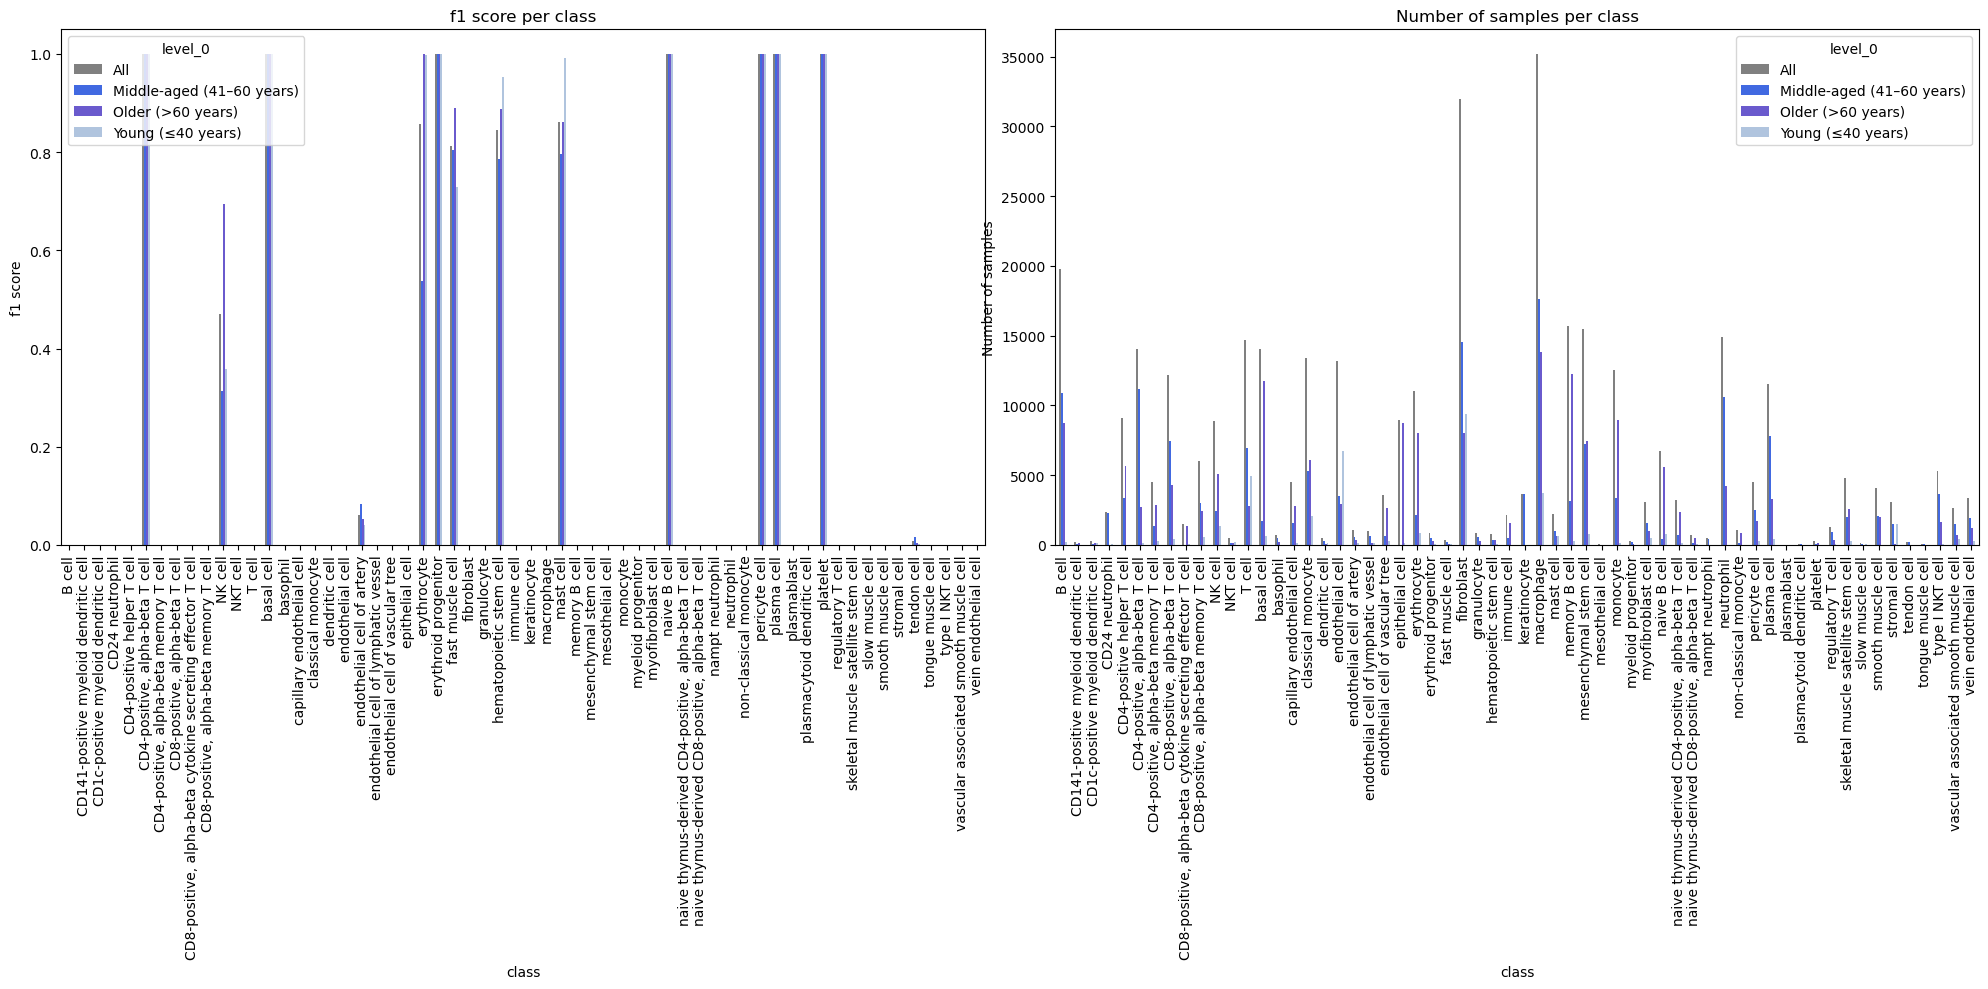

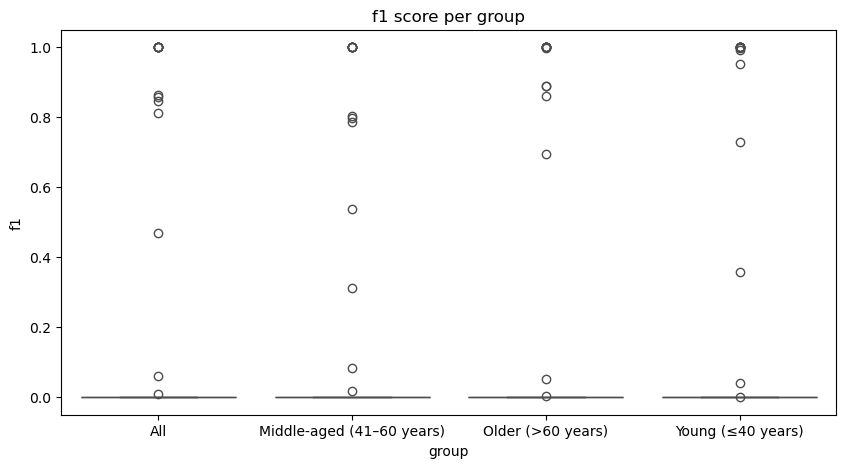

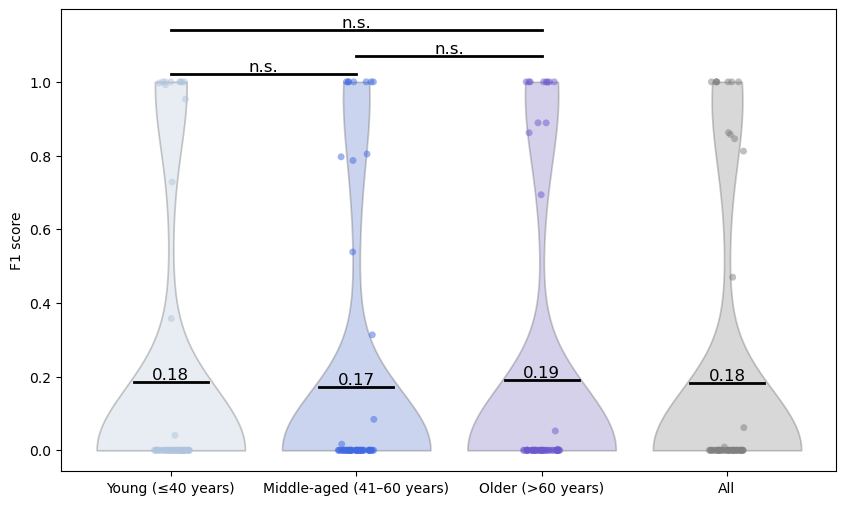

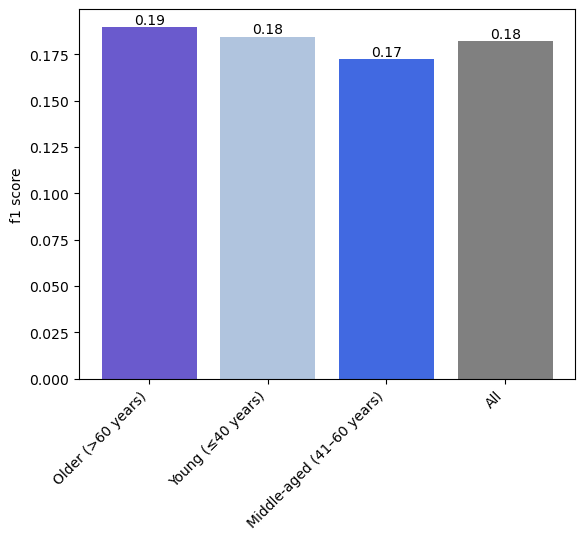

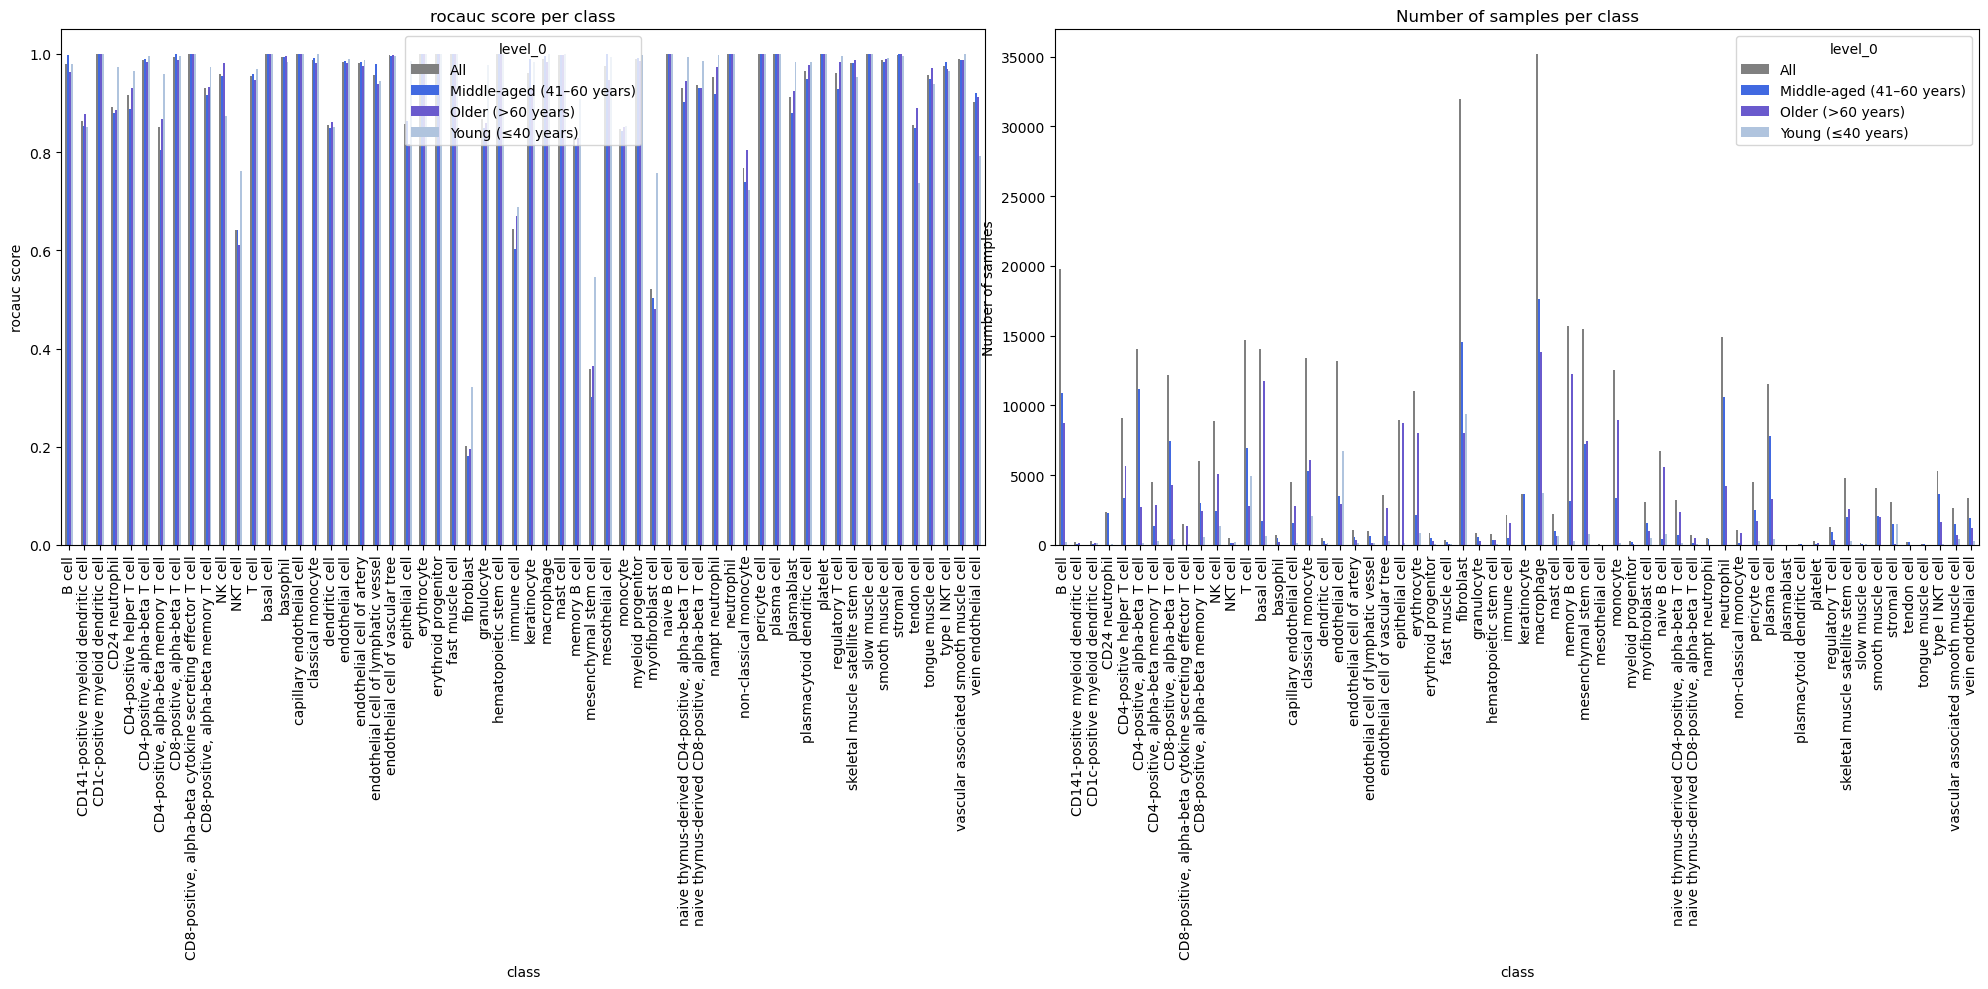

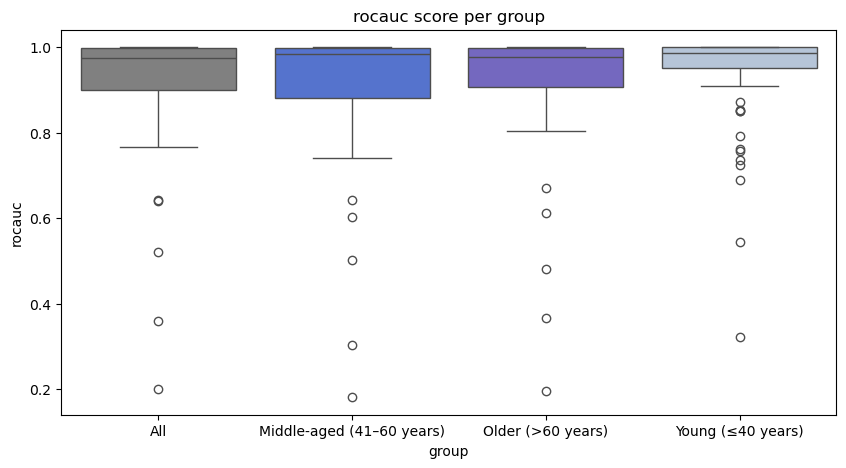

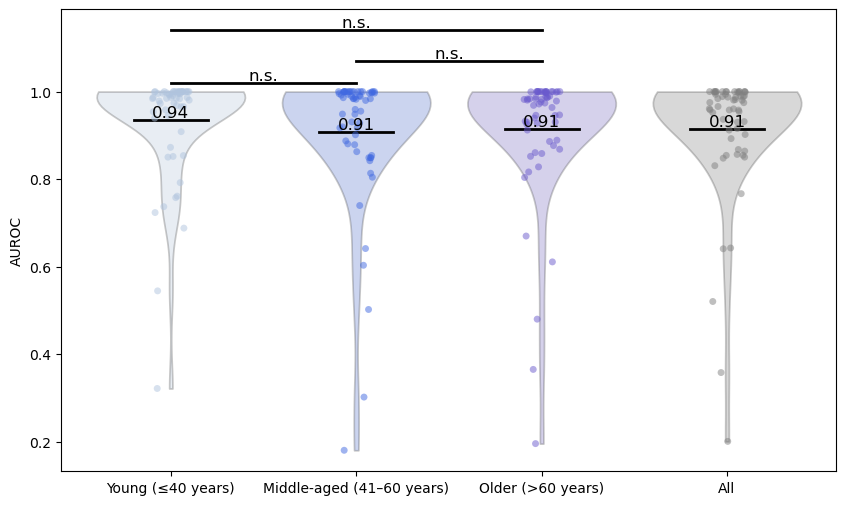

Removed classes: ['endothelial cell of hepatic sinusoid', 'liver dendritic cell', 'hepatocyte', 'intrahepatic cholangiocyte', 'tracheal goblet cell', 'ionocyte', 'mucus secreting cell', 'serous cell of epithelium of trachea', 'double-positive, alpha-beta thymocyte', 'fibroblast of breast', 'luminal epithelial cell of mammary gland', 'epithelial cell of uterus', 'ciliated epithelial cell', 'myometrial cell', 'epithelial cell of lacrimal sac', 'retinal pigment epithelial cell', 'leucocyte', 'NKT cell', 'muscle cell', 'CD8-positive, alpha-beta cytotoxic T cell', 'langerhans cell', 'cardiac endothelial cell', 'cardiac muscle cell', 'fibroblast of cardiac tissue', 'basal cell of prostate epithelium', 'hillock-club cell of prostate epithelium', 'CD8b-positive NKT cell', 'luminal cell of prostate epithelium', 'salivary gland cell', 'naive regulatory T cell', 't follicular helper cell', 'DN4 thymocyte', 'myeloid dendritic cell', 'adipocyte', 'retinal ganglion cell', 'enterocyte of epithelium o

,gender
male,214733
female,213683


,precision_macroAvg,accuracy_macroAvg,f1_macroAvg,rocauc_macroAvg,recall_at_1_macroAvg,recall_at_5_macroAvg,recall_at_10_macroAvg,recall_at_50_macroAvg
male,0.129180,0.213592,0.138713,0.898971,0.213592,0.572816,0.747573,0.961165
female,0.130285,0.213592,0.137831,0.899294,0.213592,0.572816,0.747573,0.961165
All,0.129295,0.213592,0.138066,0.899138,0.213592,0.572816,0.747573,0.961165


Performing paired t-tests for metric: precision
Comparing male and female
TtestResult(statistic=-0.14975079311384104, pvalue=0.8812569412767317, df=102)
Performing paired t-tests for metric: accuracy
Comparing male and female
TtestResult(statistic=nan, pvalue=nan, df=102)
Performing paired t-tests for metric: f1
Comparing male and female
TtestResult(statistic=0.15194066556626526, pvalue=0.8795338613693583, df=102)
Performing paired t-tests for metric: rocauc
Comparing male and female
TtestResult(statistic=-0.11140325839216088, pvalue=0.9115155016593082, df=102)
Performing paired t-tests for metric: recall_at_1
Comparing male and female
TtestResult(statistic=nan, pvalue=nan, df=102)
Performing paired t-tests for metric: recall_at_5
Comparing male and female
TtestResult(statistic=nan, pvalue=nan, df=102)
Performing paired t-tests for metric: recall_at_10
Comparing male and female
TtestResult(statistic=nan, pvalue=nan, df=102)


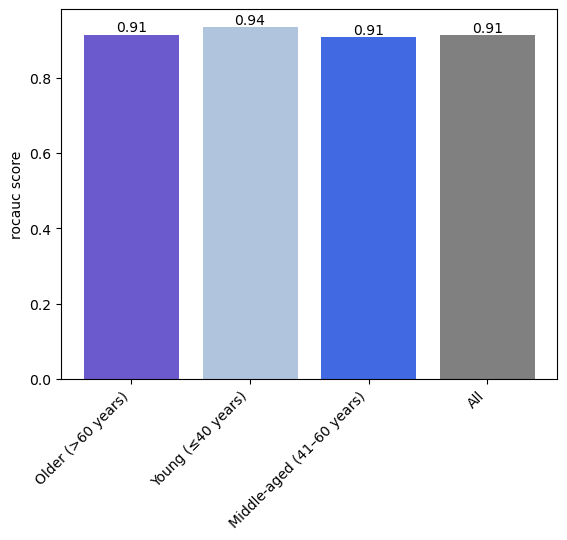

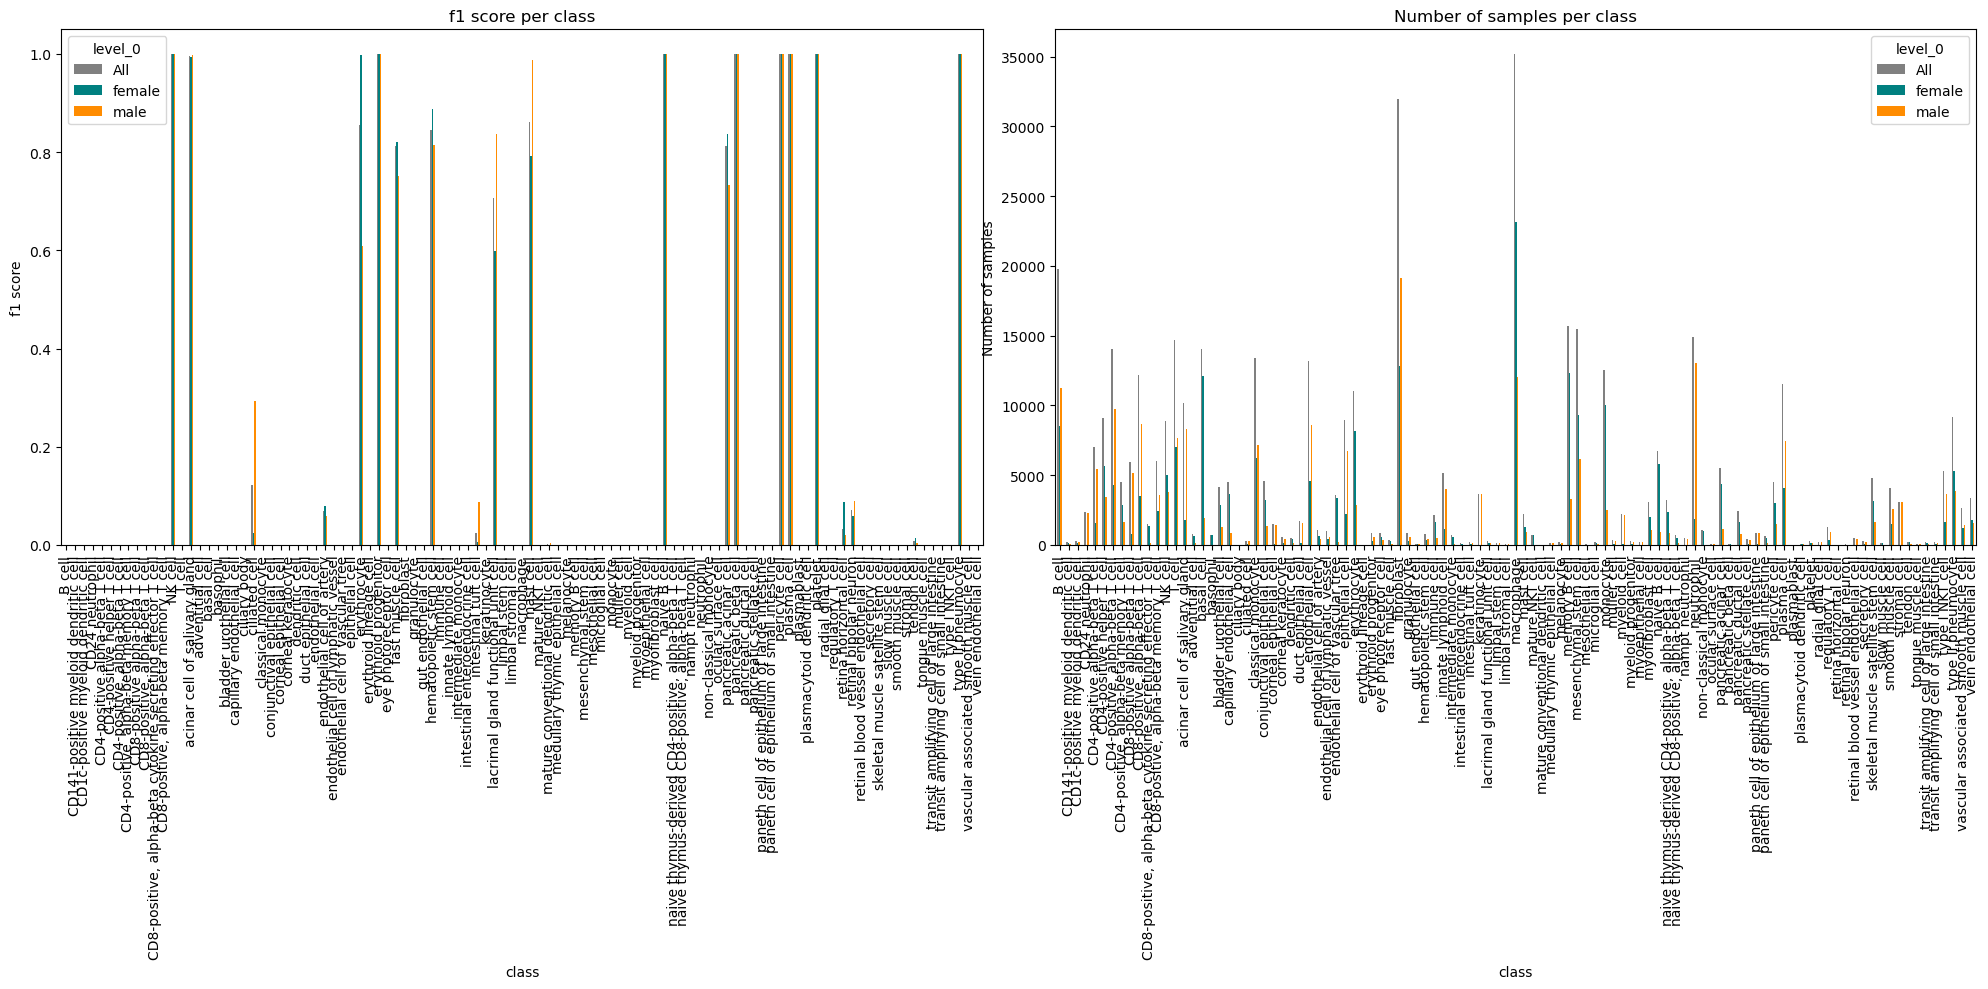

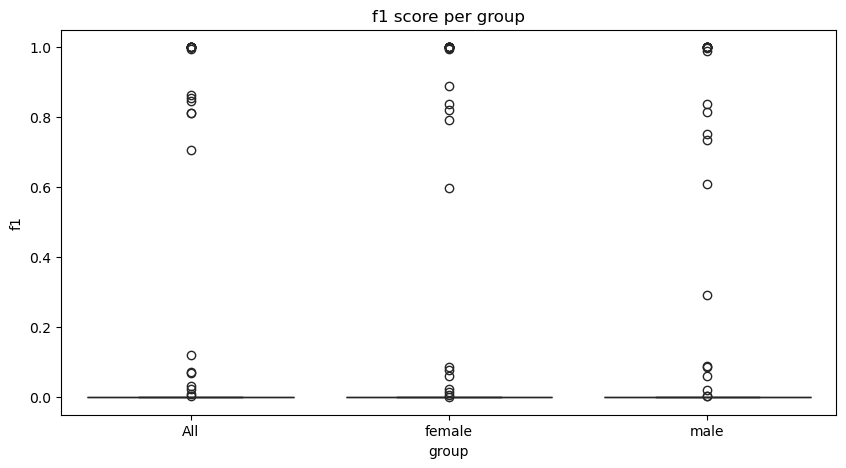

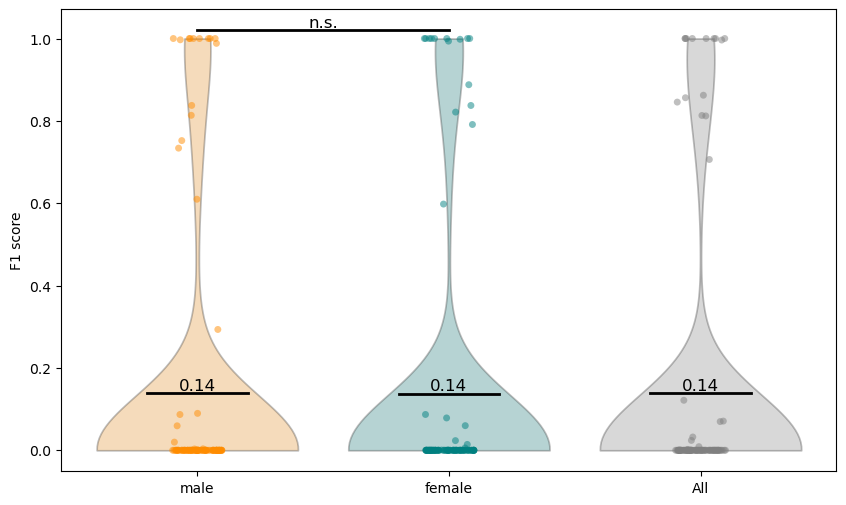

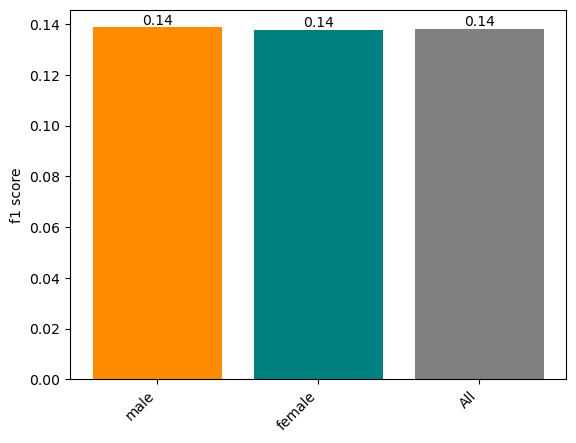

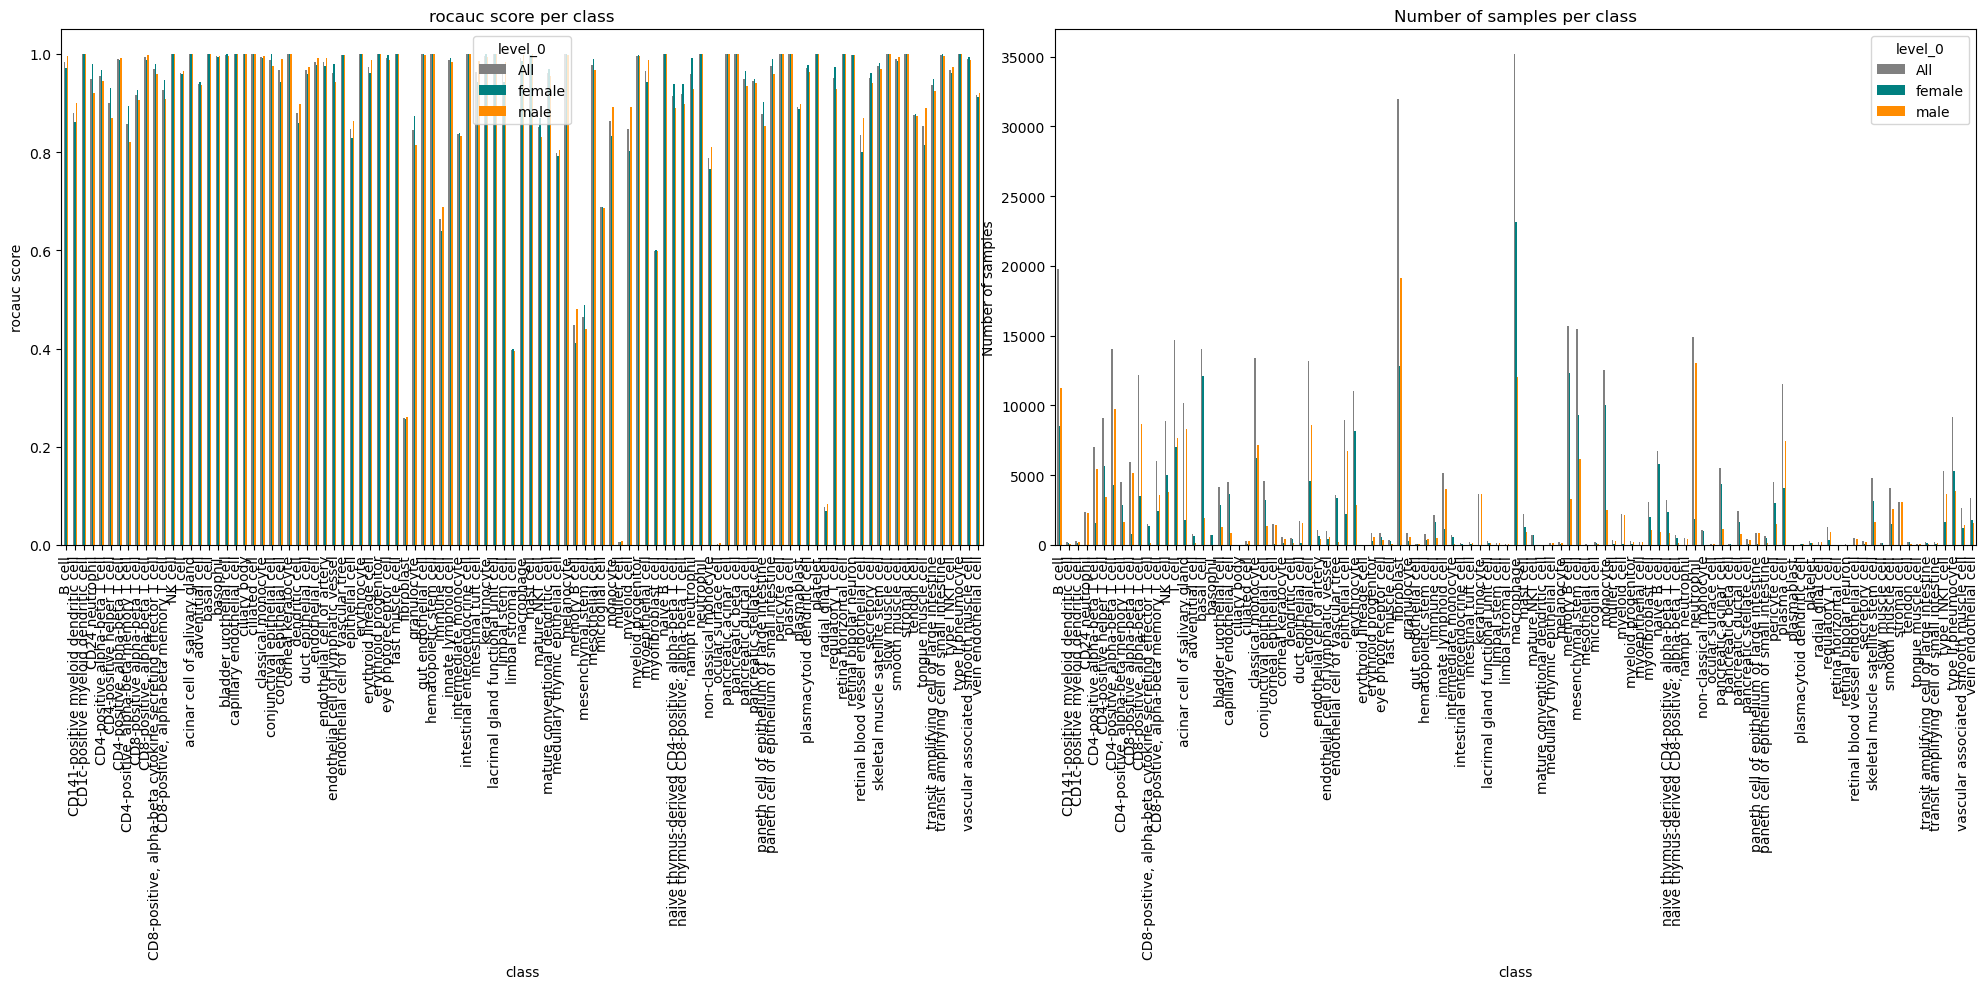

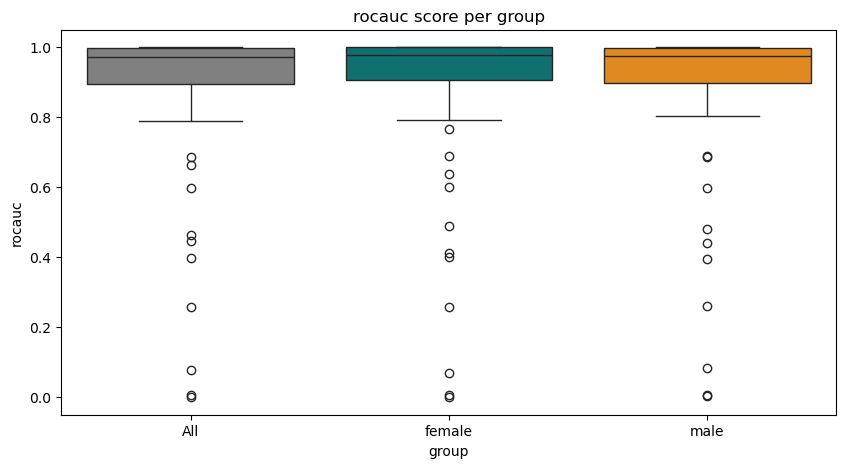

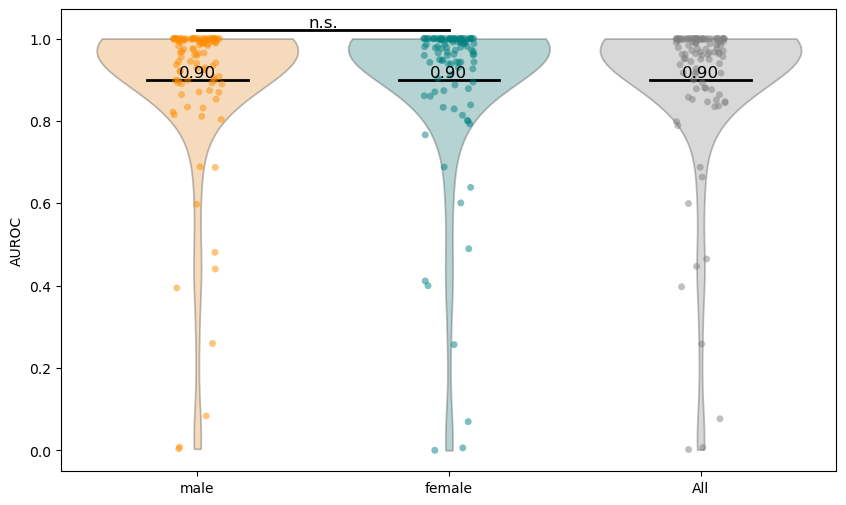

Removed classes: ['Liver', 'Trachea', 'Lymph_Node', 'Salivary_Gland', 'Spleen', 'Mammary', 'Uterus', 'Eye', 'Fat', 'Skin', 'Heart', 'Pancreas', 'Prostate', 'Thymus', 'Bladder', 'Large_Intestine', 'Lung', 'Small_Intestine', 'Vasculature', 'Kidney']


,age_group
Older (>60 years),60389
Middle-aged (41–60 years),39813
Young (≤40 years),7976


,precision_macroAvg,accuracy_macroAvg,f1_macroAvg,rocauc_macroAvg,recall_at_1_macroAvg,recall_at_5_macroAvg,recall_at_10_macroAvg,recall_at_50_macroAvg
Older (>60 years),0.475321,0.5,0.487020,0.667264,0.5,NaN,NaN,NaN
Young (≤40 years),0.475744,0.5,0.487254,0.696585,0.5,NaN,NaN,NaN
Middle-aged (41–60 years),0.406247,0.5,0.442306,0.620563,0.5,NaN,NaN,NaN
All,0.450743,0.5,0.472680,0.648559,0.5,NaN,NaN,NaN


Performing paired t-tests for metric: precision
Comparing Young (≤40 years) and Middle-aged (41–60 years)
TtestResult(statistic=1.0, pvalue=0.39100221895577053, df=3)
Comparing Middle-aged (41–60 years) and Older (>60 years)
TtestResult(statistic=-1.0, pvalue=0.39100221895577053, df=3)
Comparing Young (≤40 years) and Older (>60 years)
TtestResult(statistic=1.0, pvalue=0.39100221895577053, df=3)
Performing paired t-tests for metric: accuracy
Comparing Young (≤40 years) and Middle-aged (41–60 years)
TtestResult(statistic=nan, pvalue=nan, df=3)
Comparing Middle-aged (41–60 years) and Older (>60 years)
TtestResult(statistic=nan, pvalue=nan, df=3)
Comparing Young (≤40 years) and Older (>60 years)
TtestResult(statistic=nan, pvalue=nan, df=3)
Performing paired t-tests for metric: f1
Comparing Young (≤40 years) and Middle-aged (41–60 years)
TtestResult(statistic=1.0, pvalue=0.39100221895577053, df=3)
Comparing Middle-aged (41–60 years) and Older (>60 years)
TtestResult(statistic=-1.0, pvalue=0

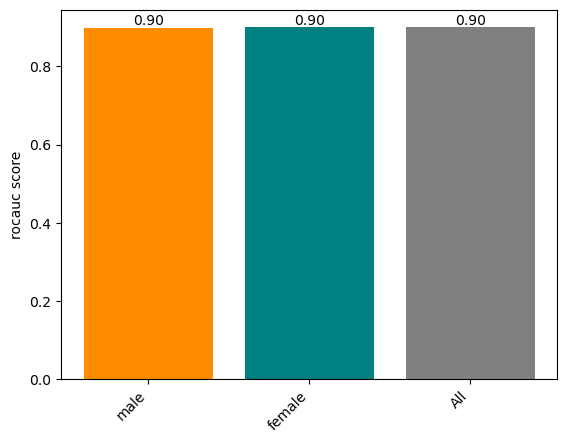

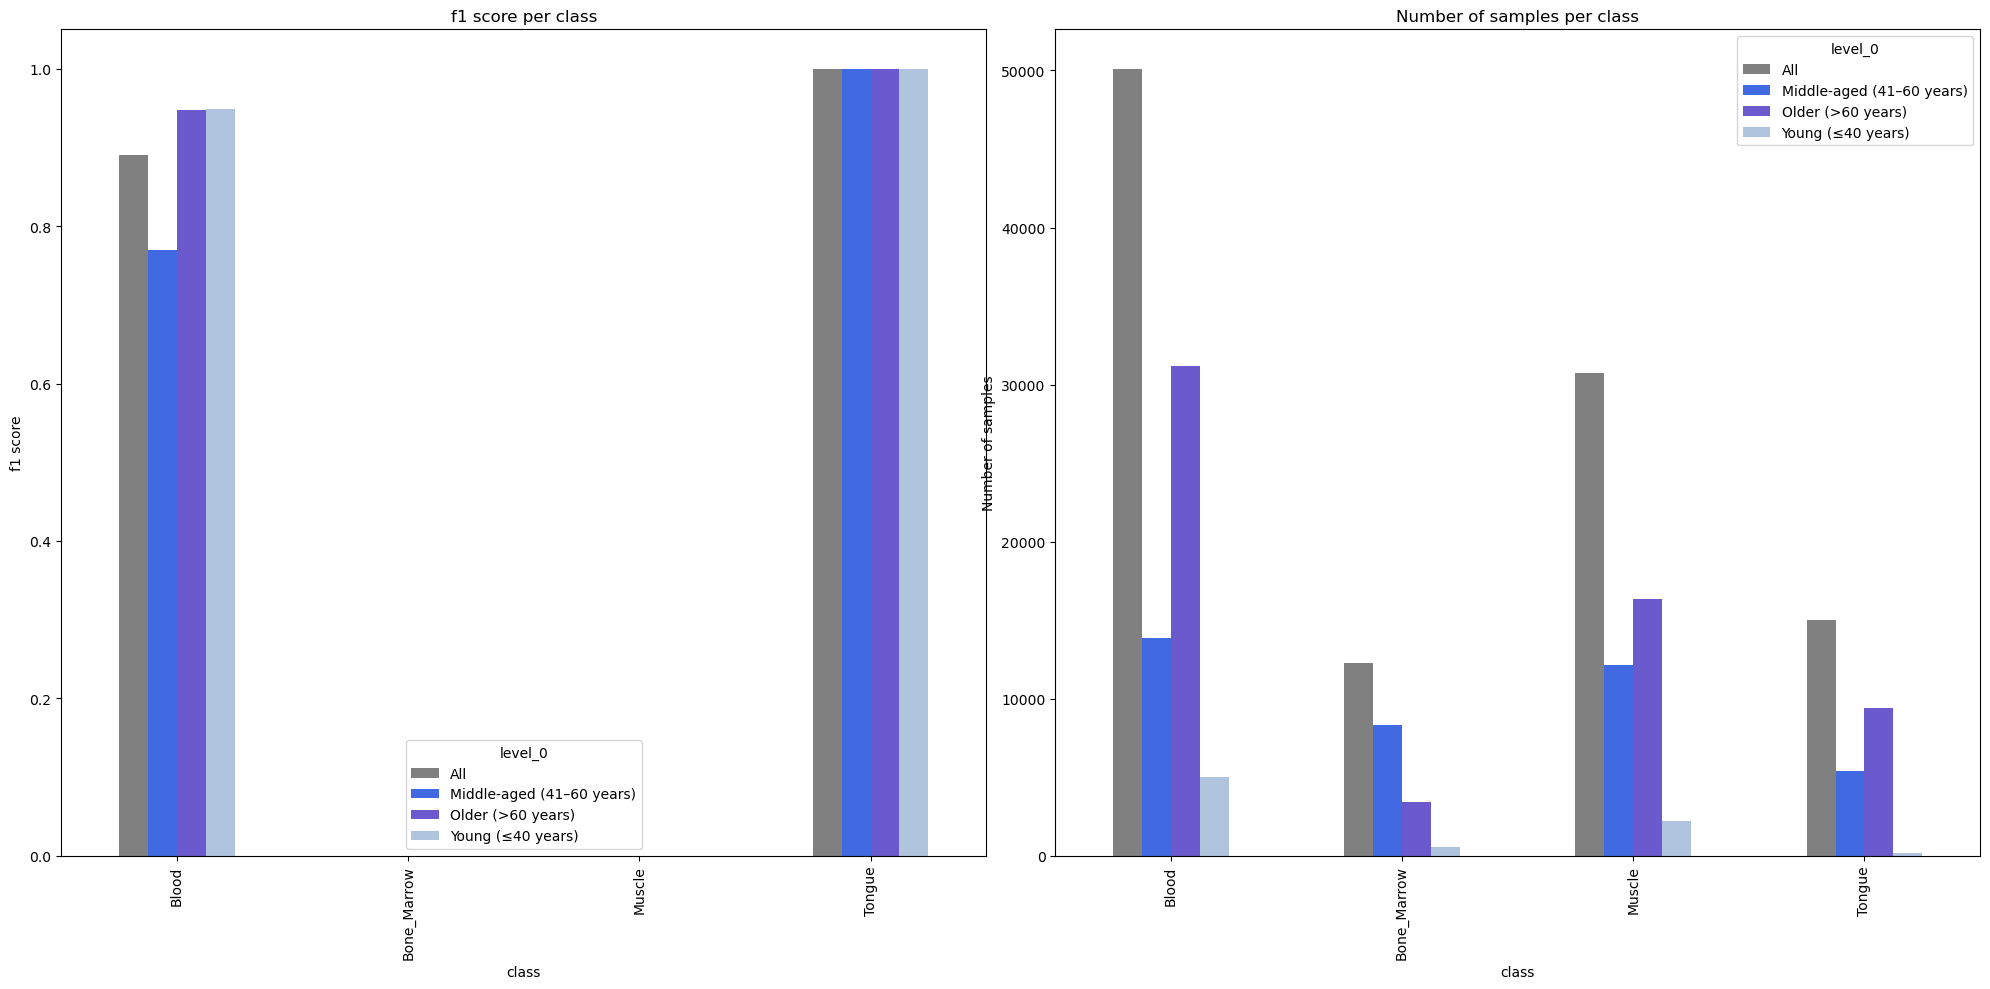

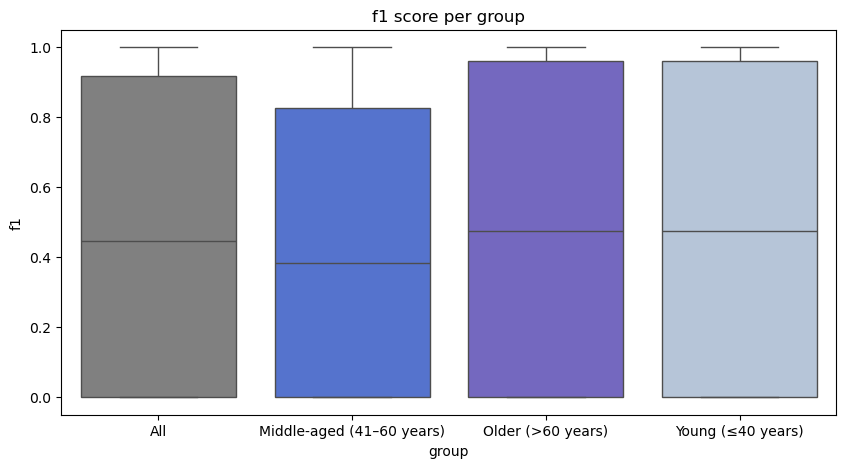

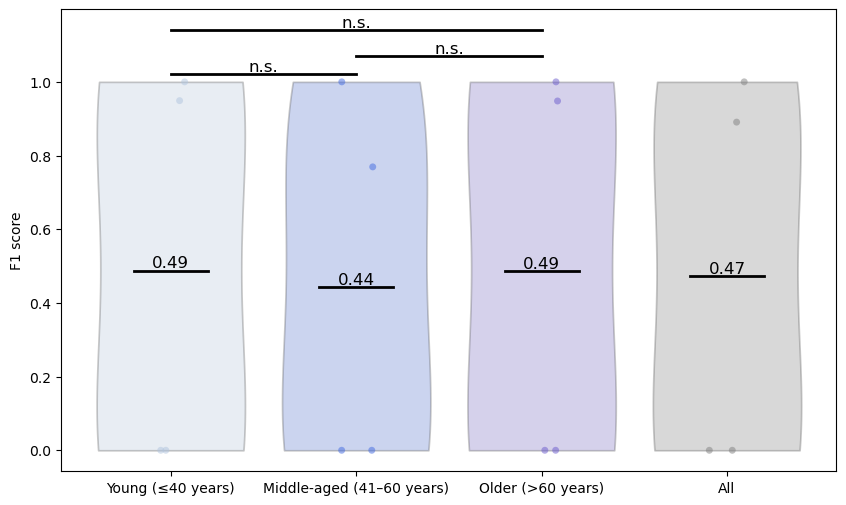

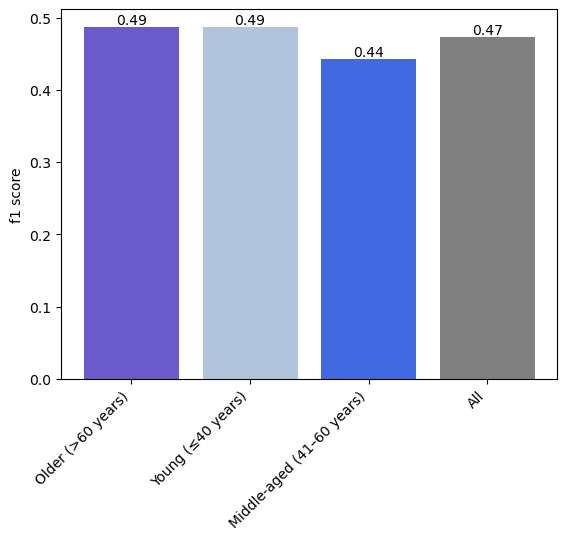

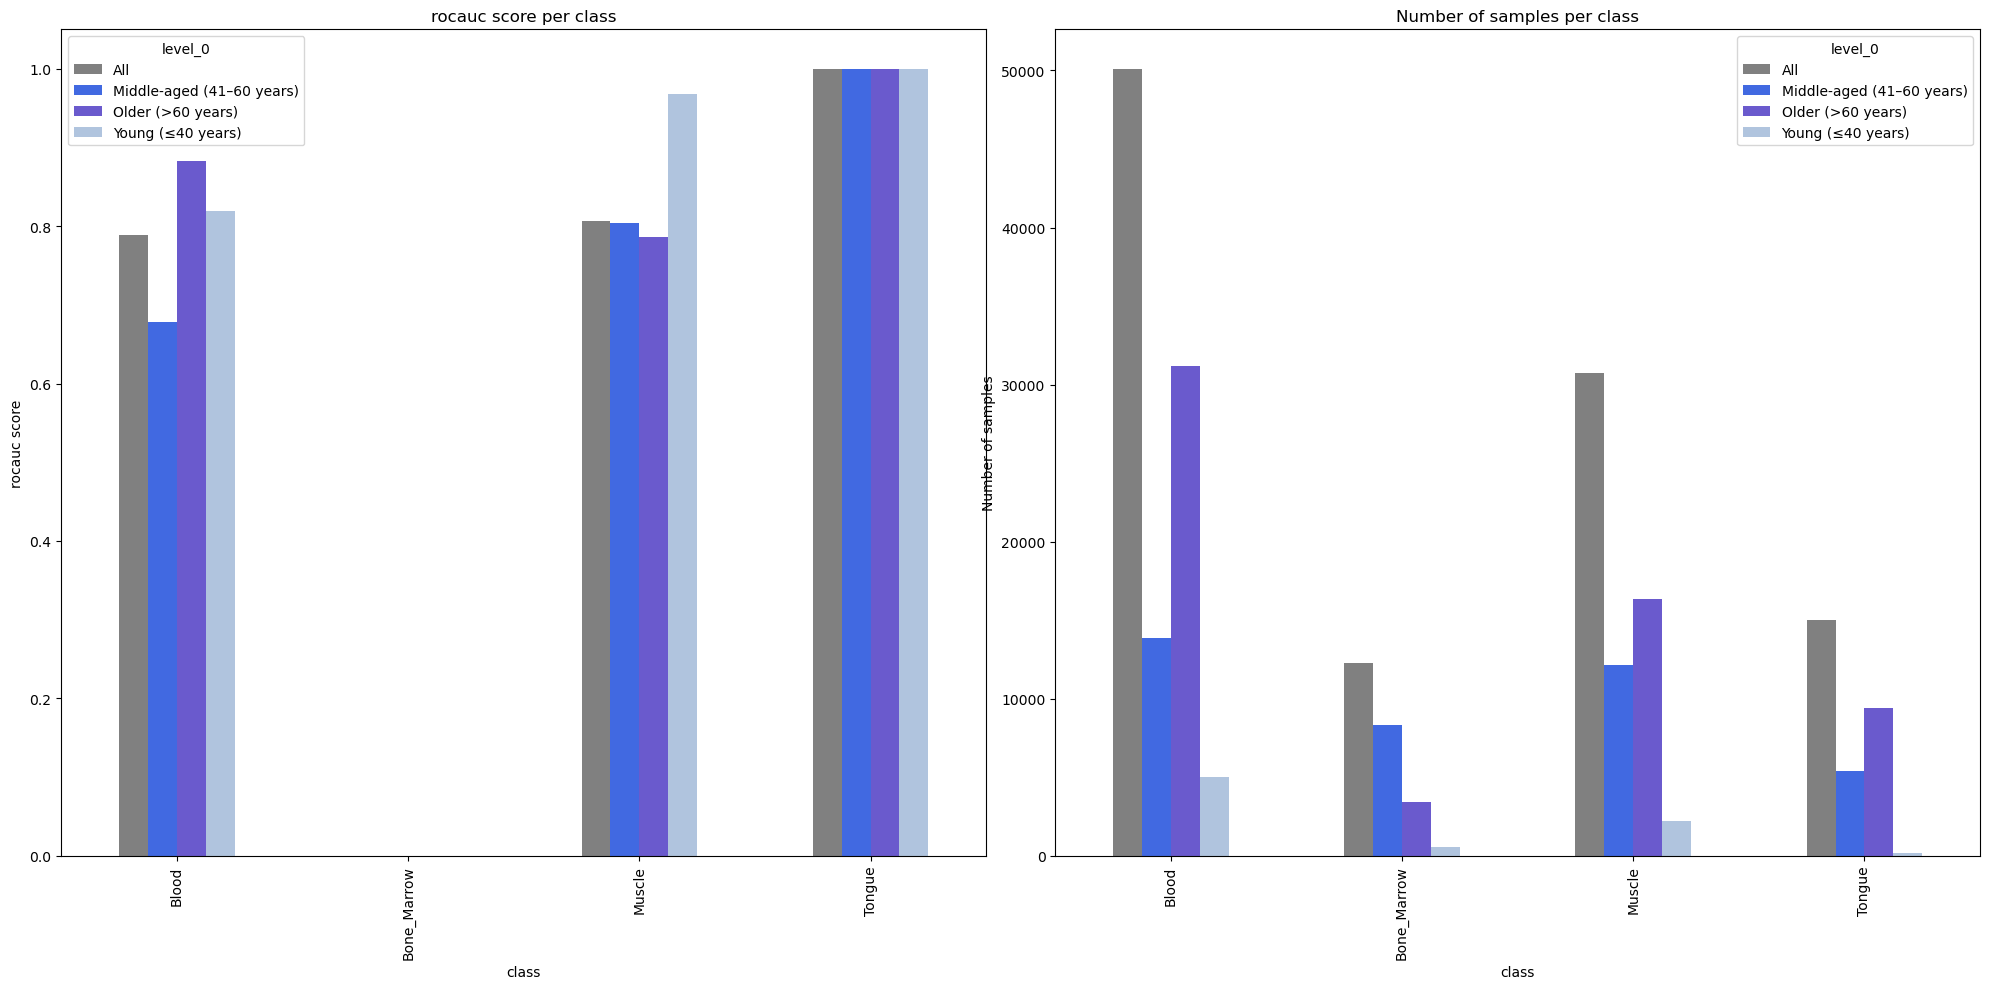

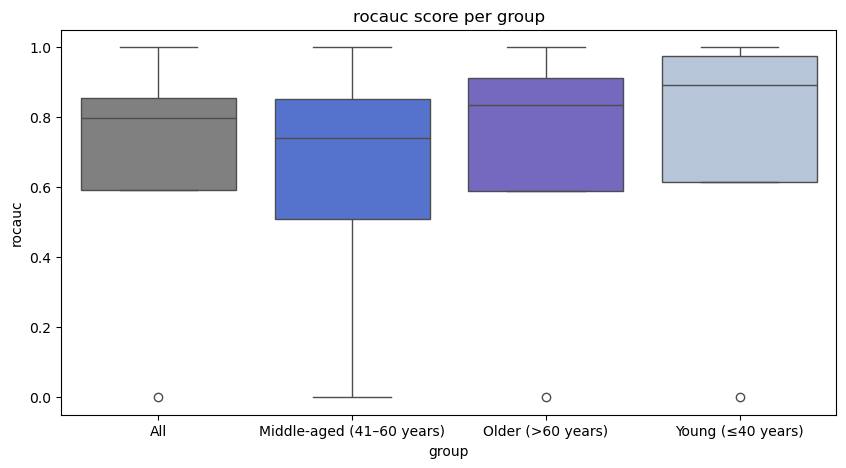

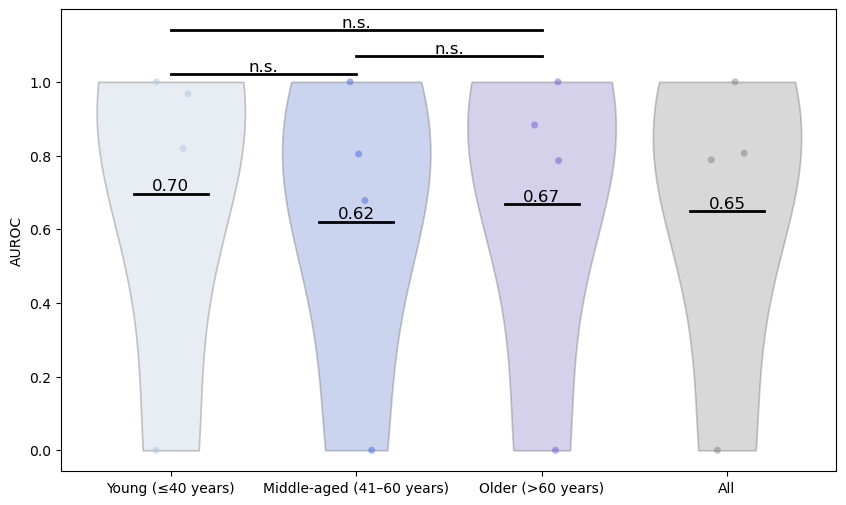

Removed classes: ['Liver', 'Mammary', 'Uterus', 'Fat', 'Skin', 'Heart', 'Prostate', 'Kidney']


,gender
female,209944
male,182494


,precision_macroAvg,accuracy_macroAvg,f1_macroAvg,rocauc_macroAvg,recall_at_1_macroAvg,recall_at_5_macroAvg,recall_at_10_macroAvg,recall_at_50_macroAvg
male,0.262294,0.3125,0.280884,0.665554,0.3125,0.5,0.8125,NaN
female,0.251864,0.3125,0.260652,0.693918,0.3125,0.5,0.8125,NaN
All,0.250851,0.3125,0.264919,0.681119,0.3125,0.5,0.8125,NaN


Performing paired t-tests for metric: precision
Comparing male and female
TtestResult(statistic=0.33321918963459124, pvalue=0.7435809094426018, df=15)
Performing paired t-tests for metric: accuracy
Comparing male and female
TtestResult(statistic=nan, pvalue=nan, df=15)
Performing paired t-tests for metric: f1
Comparing male and female
TtestResult(statistic=0.6252828337054301, pvalue=0.5411821962933687, df=15)
Performing paired t-tests for metric: rocauc
Comparing male and female
TtestResult(statistic=-1.7040239601860976, pvalue=0.10899729370433334, df=15)
Performing paired t-tests for metric: recall_at_1
Comparing male and female
TtestResult(statistic=nan, pvalue=nan, df=15)
Performing paired t-tests for metric: recall_at_5
Comparing male and female
TtestResult(statistic=nan, pvalue=nan, df=15)
Performing paired t-tests for metric: recall_at_10
Comparing male and female
TtestResult(statistic=nan, pvalue=nan, df=15)


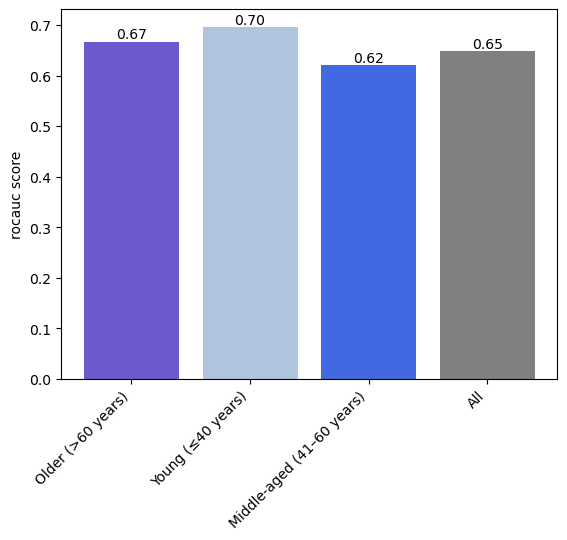

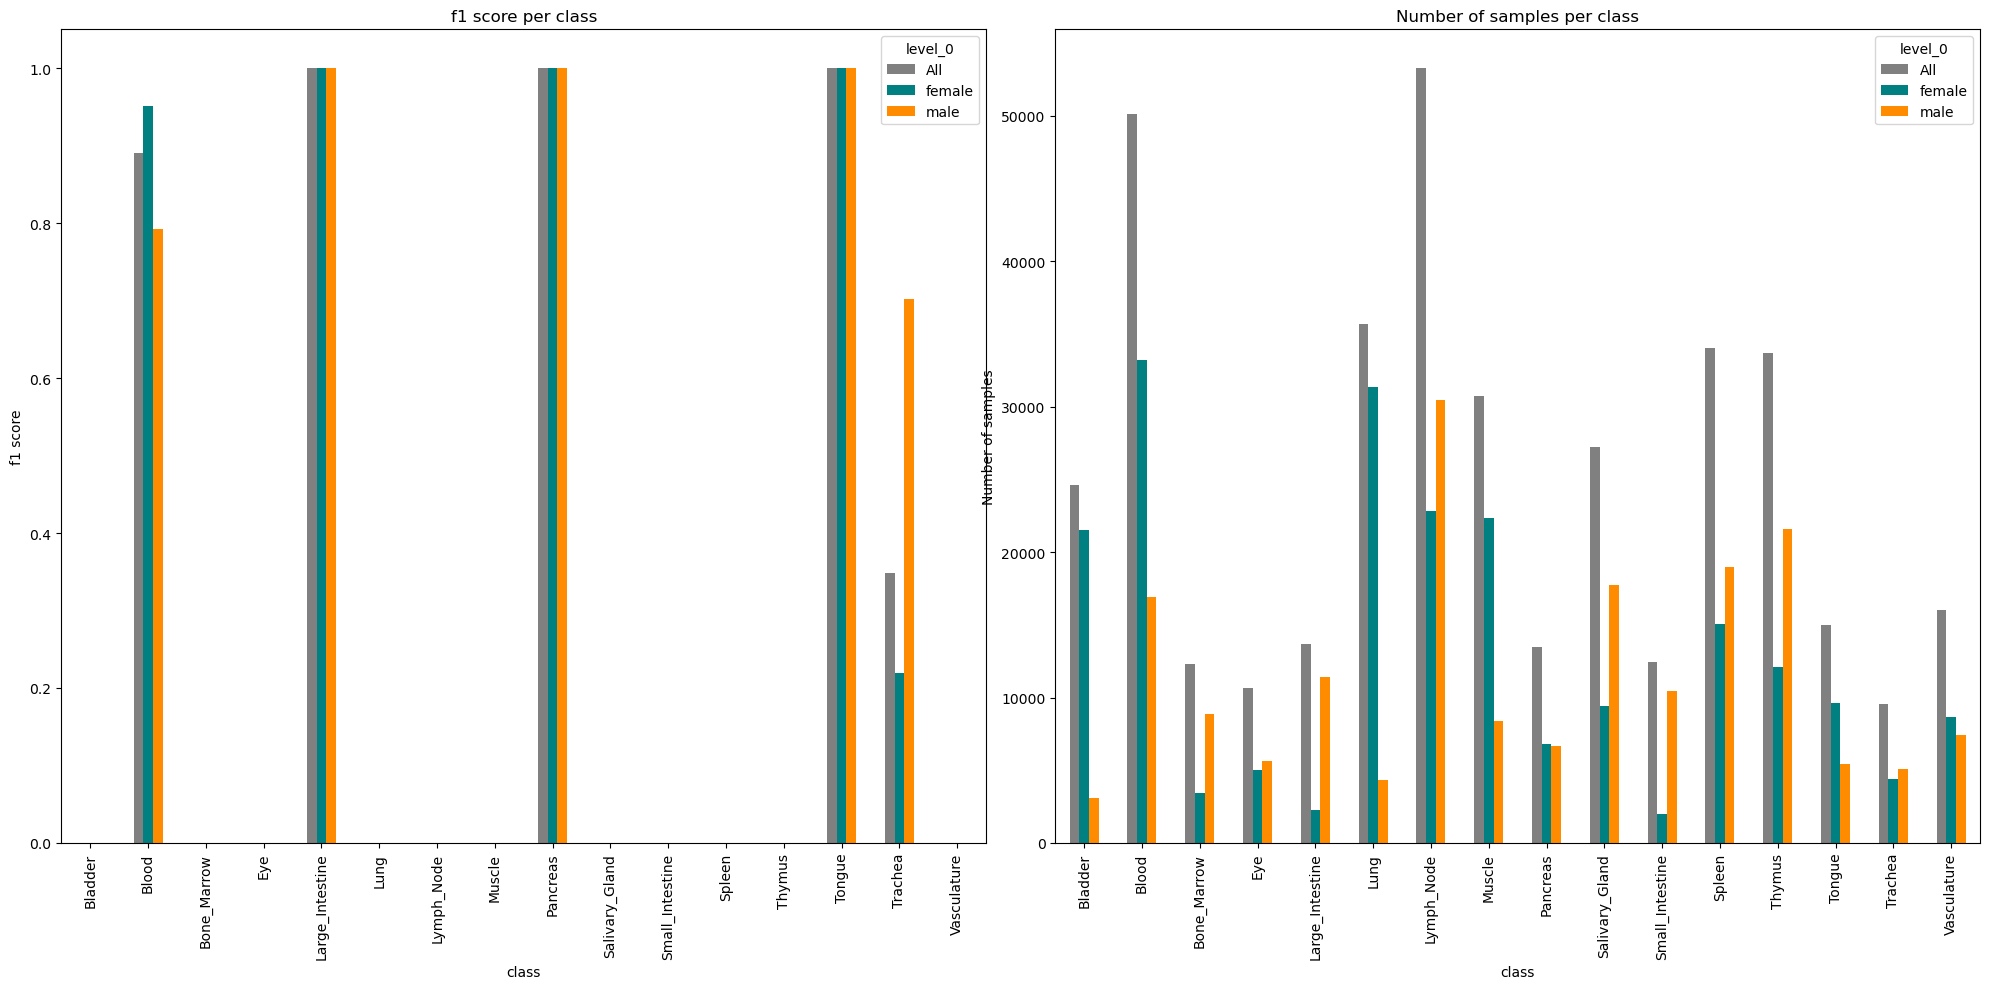

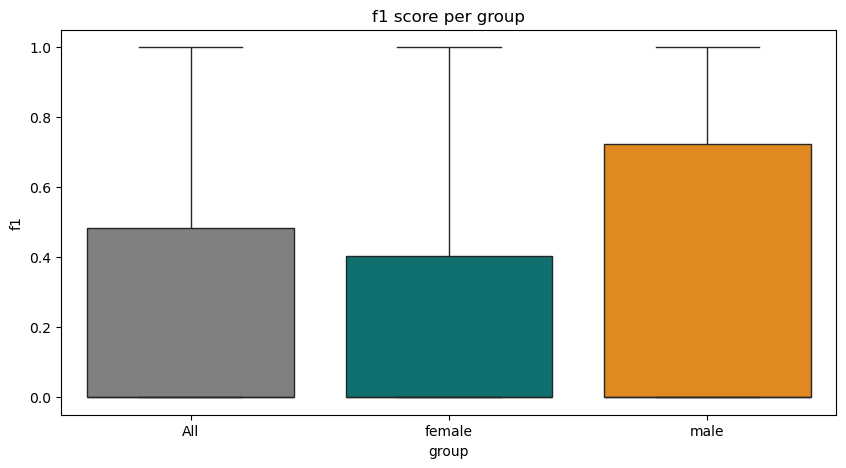

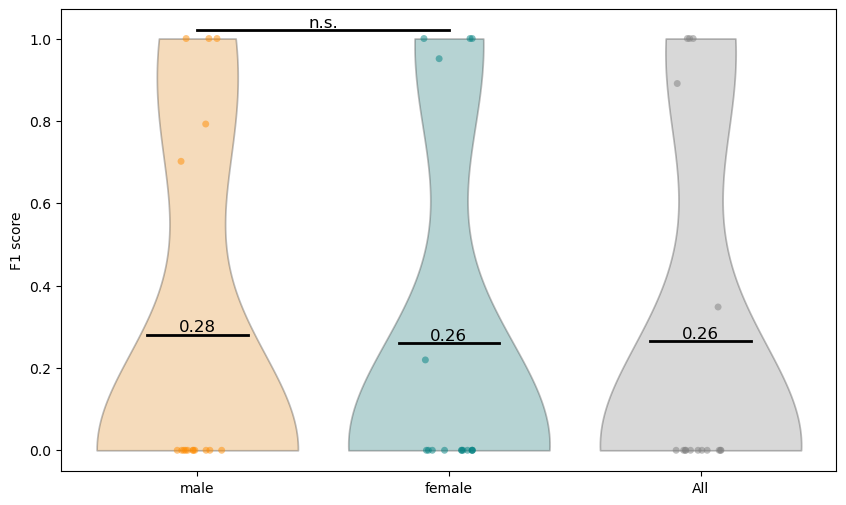

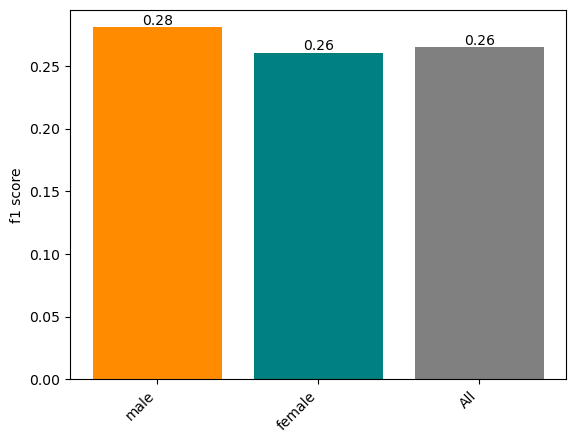

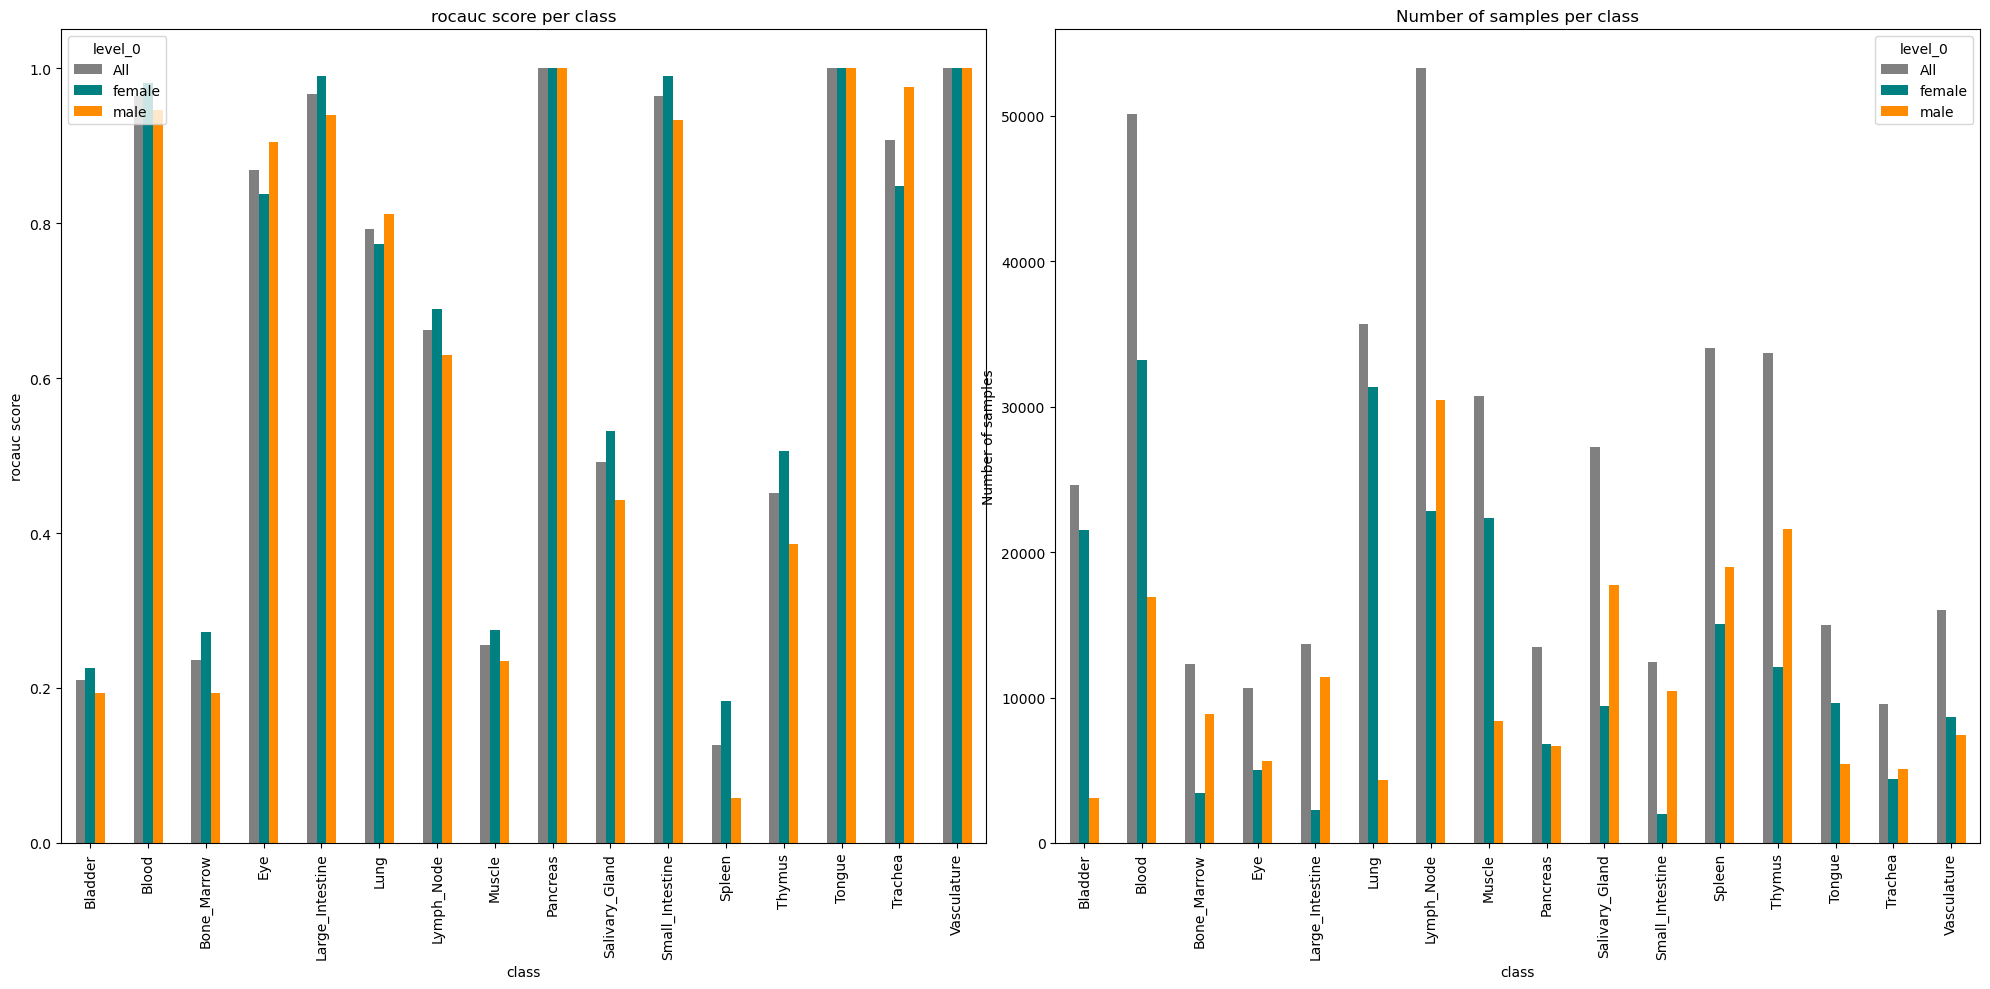

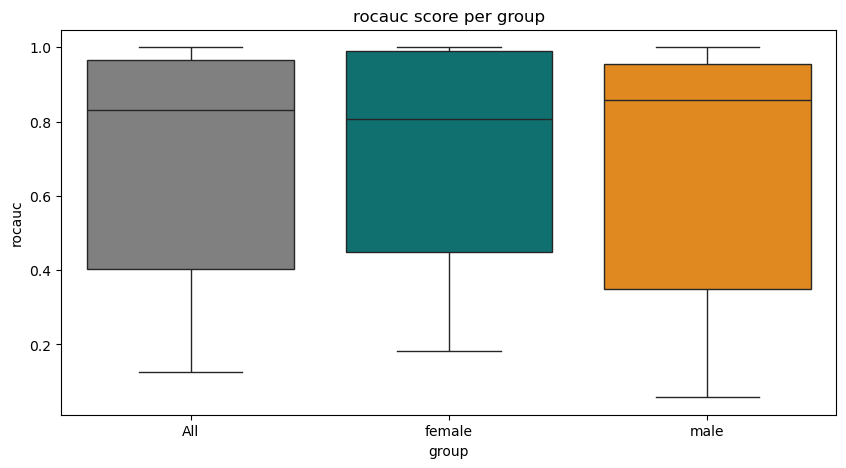

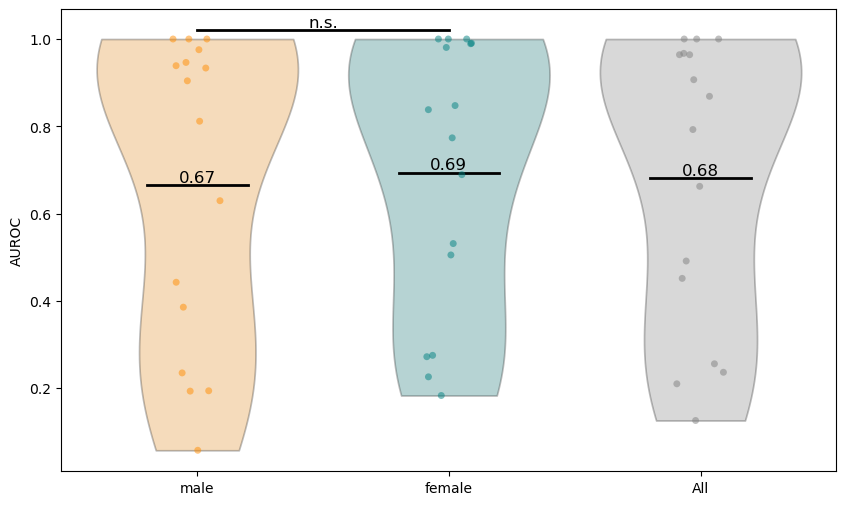

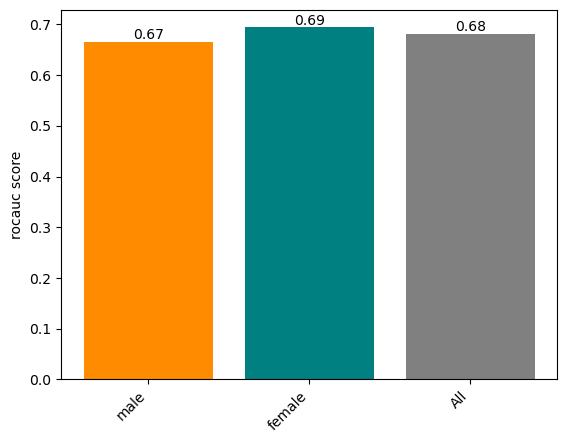

In [45]:
for dataset, label_col, group_col in zip(datasets, label_cols, group_cols):

    adata_path = f"{config['PROJECT_ROOT']}/resources/{dataset}/read_count_table.h5ad"

    adata_obs = load_and_preprocess_dataset(dataset_name=dataset, read_count_table_path = adata_path).obs
        
    scores=pd.read_csv(f"{config['PROJECT_ROOT']}/results/plots/zero_shot_validation/{model}/datasets/{dataset}/predictions/{label_col}.by_cell.csv") #{label_col}.csv")
    assert all(scores.sample_name == adata_obs.index), "The indices of the scores and the adata_obs do not match. Please check the data."
    scores = pd.merge(scores, adata_obs, left_on="sample_name", right_index=True)
    
    scores["age_group"] = scores["donor"].map(donor_to_age_group_dict)

    prefix,suffix = SUFFIX_PREFIX_DICT[label_col]

    results = {}
    results_per_class = {}

    # keep only cells of types or organs that appear in all groups
    keep_classes = scores[label_col].unique()
    for group in list(scores[group_col].unique()):
        keep_classes = set(keep_classes).intersection(scores[scores[group_col] == group][label_col].unique())
    remove_classes=[x for x in scores[label_col].unique() if not x in keep_classes]
    scores = scores[scores[label_col].isin(keep_classes)]
    for remove_class in remove_classes:
        remove_col = f"score_for_{prefix}{remove_class}{suffix}"
        scores = scores.drop(remove_col,axis=1)

    print(f"Removed classes: {remove_classes}")
    display(pd.DataFrame(scores[group_col].value_counts()))

    for group in list(scores[group_col].unique())+["All"]:
        scores_subset = scores[scores[group_col] == group] if not group == "All" else scores
        classes=[x.replace(suffix,"").replace(prefix,"").replace("score_for_","") for x in scores_subset.columns if x.startswith("score_for_")]

        true_class_indices = scores_subset.apply(lambda x: classes.index(x[label_col]),axis=1).values
        
        assert sorted(set(scores_subset[label_col].unique())) == sorted(set(classes)), "The classes in the data do not match the classes in the scores"

        scores_subset = scores_subset[[x for x in scores_subset.columns if x.startswith("score_for_")]]

        num_classes = len(classes)
        
        torchmetric_kwargs = {
            "preds": torch.Tensor(scores_subset.values),
            "target": torch.Tensor(true_class_indices).long(),
            "num_classes": num_classes,
            "average": "none",
            "top_k": 1,
        }

        precision = torchmetrics.functional.classification.multiclass_precision(
            **torchmetric_kwargs
        )
        accuracy = torchmetrics.functional.classification.multiclass_accuracy(
            **torchmetric_kwargs
        )
        f1 = torchmetrics.functional.classification.multiclass_f1_score(
            **torchmetric_kwargs
        )
        rocauc = torchmetrics.functional.classification.multiclass_auroc(
            **{k: v for k, v in torchmetric_kwargs.items() if not k == "top_k"}
        )

        confusion_mtx = torchmetrics.functional.classification.multiclass_confusion_matrix(
            **{k: v for k, v in torchmetric_kwargs.items() if k not in ["top_k", "average"]}
        )

        res_metrics = {
            "precision": precision.detach(),
            "accuracy": accuracy.detach(),
            "f1": f1.detach(),
            "rocauc": rocauc.detach(),
        }

        for k in [1, 5, 10, 50]:
            if num_classes >= k:
                torchmetric_kwargs.update({"top_k": k})
                res_metrics[
                    f"recall_at_{k}"
                ] = torchmetrics.functional.classification.multiclass_recall(
                    **torchmetric_kwargs
                ).detach()
                torchmetric_kwargs.update({"top_k": 1})
            else:
                res_metrics[f"recall_at_{k}"] = torch.tensor([np.nan] * num_classes)

        macro_average_results = {}
        for metric, value in res_metrics.items():
            macro_average_results[f"{metric}_macroAvg"] = value.mean().item()
        
        results[group] = macro_average_results

        # Create a dataframe with per-class metrics. Rows: classes, columns: metrics. Rownames: class names, column names: metric names
        text_annotations = classes

        per_class_df = pd.DataFrame(
            torch.stack([value for value in res_metrics.values()], dim=1).numpy(),
            columns=[x for x in res_metrics.keys()],
            index=text_annotations,
        )
        per_class_df.index.name = "class"
        per_class_df["n_samples_in_class"] = [
            list(true_class_indices).count(class_idx)
            for class_idx, _ in enumerate(text_annotations)
        ]

        confusion_df = pd.DataFrame(
            confusion_mtx.numpy(),
            index=text_annotations,
            columns=[f"n_samples_predicted_as_{x}" for x in text_annotations],
        )
        confusion_df.index.name = "class"
        per_class_df = pd.concat([per_class_df, confusion_df], axis=1)

        results_per_class[group] = per_class_df


    results_df = pd.DataFrame(results).T
    # now display the results in the jupyter notebook
    display(results_df)

        # Plot the results df as a bar plot (F1 only).Lighter colors for younger, darker for older
    if group_col == "age_group":
        color_dict = {"Older (>60 years)": "slateblue", "Middle-aged (41–60 years)": "royalblue", "Young (≤40 years)": "lightsteelblue", "All": "grey"}
    else:
        color_dict = {"male":"darkorange", "female":"teal", "All": "grey"}



    results_per_class_df = pd.concat(results_per_class.values(), keys=results_per_class)


    # Perform paired t-tests between the groups (male vs. female) for each metric. samples = classes


    for metric in ["precision",	"accuracy",	"f1",	"rocauc",	"recall_at_1",	"recall_at_5",	"recall_at_10"]:
        
        print(f"Performing paired t-tests for metric: {metric}")
        if group_col == "age_group":
            for group1, group2 in [("Young (≤40 years)", "Middle-aged (41–60 years)"), ("Middle-aged (41–60 years)", "Older (>60 years)"), ("Young (≤40 years)", "Older (>60 years)")]:
                print(f"Comparing {group1} and {group2}")
                print(ttest_rel(results_per_class_df.loc[group1][metric].loc[sorted(list(keep_classes))], results_per_class_df.loc[group2][metric].loc[sorted(list(keep_classes))]))
        else:
            group1, group2 = ("male","female")
            print(f"Comparing {group1} and {group2}")
            print(ttest_rel(results_per_class_df.loc[group1][metric].loc[sorted(list(keep_classes))], results_per_class_df.loc[group2][metric].loc[sorted(list(keep_classes))]))


    for metric in ["f1","rocauc"]:
        fig, ax = plt.subplots( 1,2 ,figsize=(20, 10))

        metric_pivot = results_per_class_df[[metric]].reset_index().rename(columns={"class":"class"}).pivot(index="class", columns="level_0", values=metric)
        metric_pivot.plot.bar(ax=ax[0],color=[color_dict[x] for x in metric_pivot.columns])

        nsample_pivot=results_per_class_df[["n_samples_in_class"]].reset_index().rename(columns={"class":"class"}).pivot(index="class", columns="level_0", values="n_samples_in_class")
        nsample_pivot.plot.bar(ax=ax[1],color=[color_dict[x] for x in nsample_pivot.columns])
        # add title
        ax[0].set_title(f"{metric} score per class")
        ax[0].set_ylabel(f"{metric} score")
        ax[1].set_title("Number of samples per class")
        plt.tight_layout()
        plt.ylabel("Number of samples")
        plt.subplots_adjust(hspace=0.2)
        plt.show()

        # Plot the results as a box plot (one box per group)
        plt.figure(figsize=(10, 5))
        plt.title(f"{metric} score per group")
        longform_df = metric_pivot.reset_index().melt(id_vars=["class"], value_vars=metric_pivot.columns)
        longform_df.columns = ["class", "group", metric]
        sns.boxplot(data=longform_df, x="group", y=metric,hue="group", palette=color_dict,ax=plt.gca())
        plt.show()

        # now a combined scatter and violin plot instead of a boxplot
        plt.figure(figsize=(10, 6))
        plt.title(f"{metric} score per group")
        order=["Young (≤40 years)", "Middle-aged (41–60 years)", "Older (>60 years)", "All"] if group_col=="age_group" else ["male","female","All"]
        sns.violinplot(data=longform_df, x="group", y=metric, hue="group", palette=color_dict, ax=plt.gca(), inner=None, alpha=0.3, cut=0, order=order)
        sns.stripplot(data=longform_df, x="group", y=metric, hue="group", palette=color_dict, ax=plt.gca(), dodge=False, alpha=0.5,order=order)
        # plot the means as thick short lines
        for i, group in enumerate(order):
            mean = longform_df[longform_df["group"] == group][metric].mean()
            plt.plot([i-0.2, i+0.2], [mean, mean], color="black", lw=2)
            plt.text(i, mean, f"{mean:.2f}", ha='center', va='bottom', fontsize=12)

        plt.ylabel("AUROC" if metric == "rocauc" else "F1 score")
        plt.xlabel("")
        plt.title("")

        # plot horizontal brackets indicating "n.s."
    
        if group_col == "age_group":
            plt.plot([0, 1], [1.02, 1.02], color="black", lw=2)
            plt.text(0.5, 1.02, "n.s.", ha="center", va="bottom", fontsize=12)
            plt.plot([1, 2], [1.07, 1.07], color="black", lw=2)
            plt.text(1.5, 1.07, "n.s.", ha="center", va="bottom", fontsize=12)
            plt.plot([0, 2], [1.14, 1.14], color="black", lw=2)
            plt.text(1, 1.14, "n.s.", ha="center", va="bottom", fontsize=12)
        else:
            plt.plot([0, 1], [1.02, 1.02], color="black", lw=2)
            plt.text(0.5, 1.02, "n.s.", ha="center", va="bottom", fontsize=12)
        plt.show()

        plt.bar(results_df.index, results_df[f"{metric}_macroAvg"], color=[color_dict[x] for x in results_df.index])
        # label on top of the bars
        for i, v in enumerate(results_df[f"{metric}_macroAvg"]):
            plt.text(i, v, f"{v:.2f}", ha='center', va='bottom')
        

        plt.xticks(rotation=45, ha='right')
        plt.ylabel(f"{metric} score")



In [42]:
# Nan in pvalues occur because accuracy is 0 or 1 for all classes in both groups:
print(results_per_class_df.loc[group2]["accuracy"].loc[sorted(list(keep_classes))].unique())
print(results_per_class_df.loc[group2]["accuracy"].loc[sorted(list(keep_classes))].unique())

False
False
[0. 1.]
[0. 1.]


In [41]:
metric="accuracy"
ttest_rel(results_per_class_df.loc[group1][metric].loc[sorted(list(keep_classes))], results_per_class_df.loc[group2][metric].loc[sorted(list(keep_classes))],
nan_policy="raise")

TtestResult(statistic=nan, pvalue=nan, df=59)